<a href="https://colab.research.google.com/github/amruthaajish17/Assignment_1/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initializing MST-based Image Processing...

PROCESSING IMAGE: /content/Te-no_1.jpg
Segmenting image with k=500...
Applying segment-based denoising...
------------------------------
QUANTITATIVE METRICS
------------------------------
Computation Time:   0.72 seconds
Number of Segments: 693
Mean Squared Error: 869.79
PSNR:               18.74 dB
------------------------------


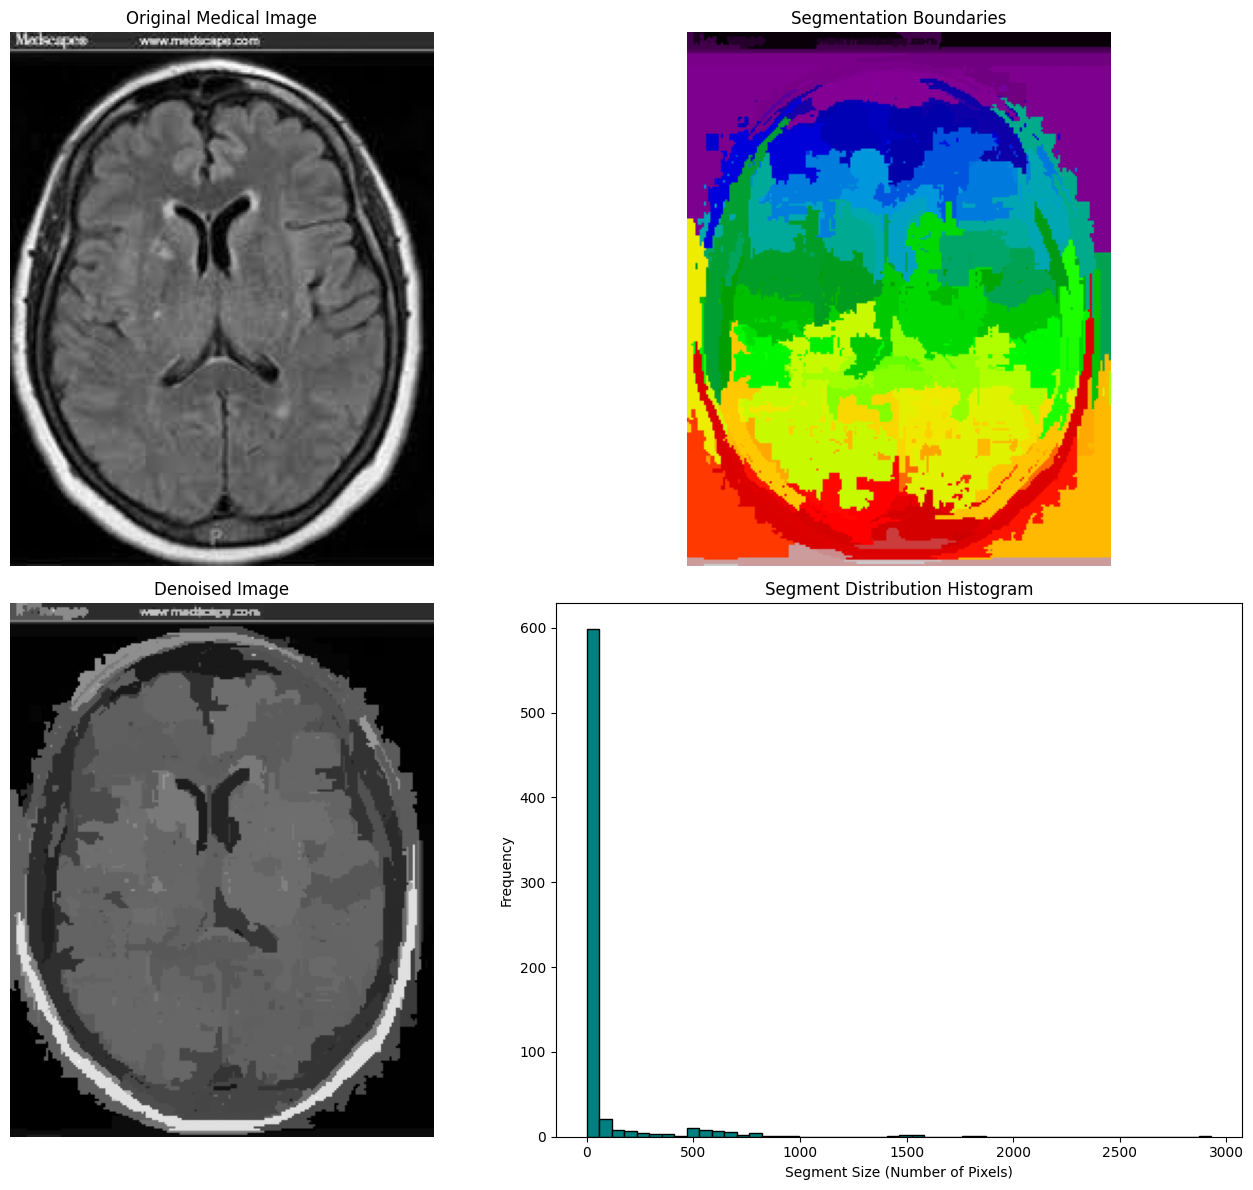


PROCESSING IMAGE: /content/Te-gl_1.jpg
Segmenting image with k=500...
Applying segment-based denoising...
------------------------------
QUANTITATIVE METRICS
------------------------------
Computation Time:   2.10 seconds
Number of Segments: 1605
Mean Squared Error: 473.66
PSNR:               21.38 dB
------------------------------


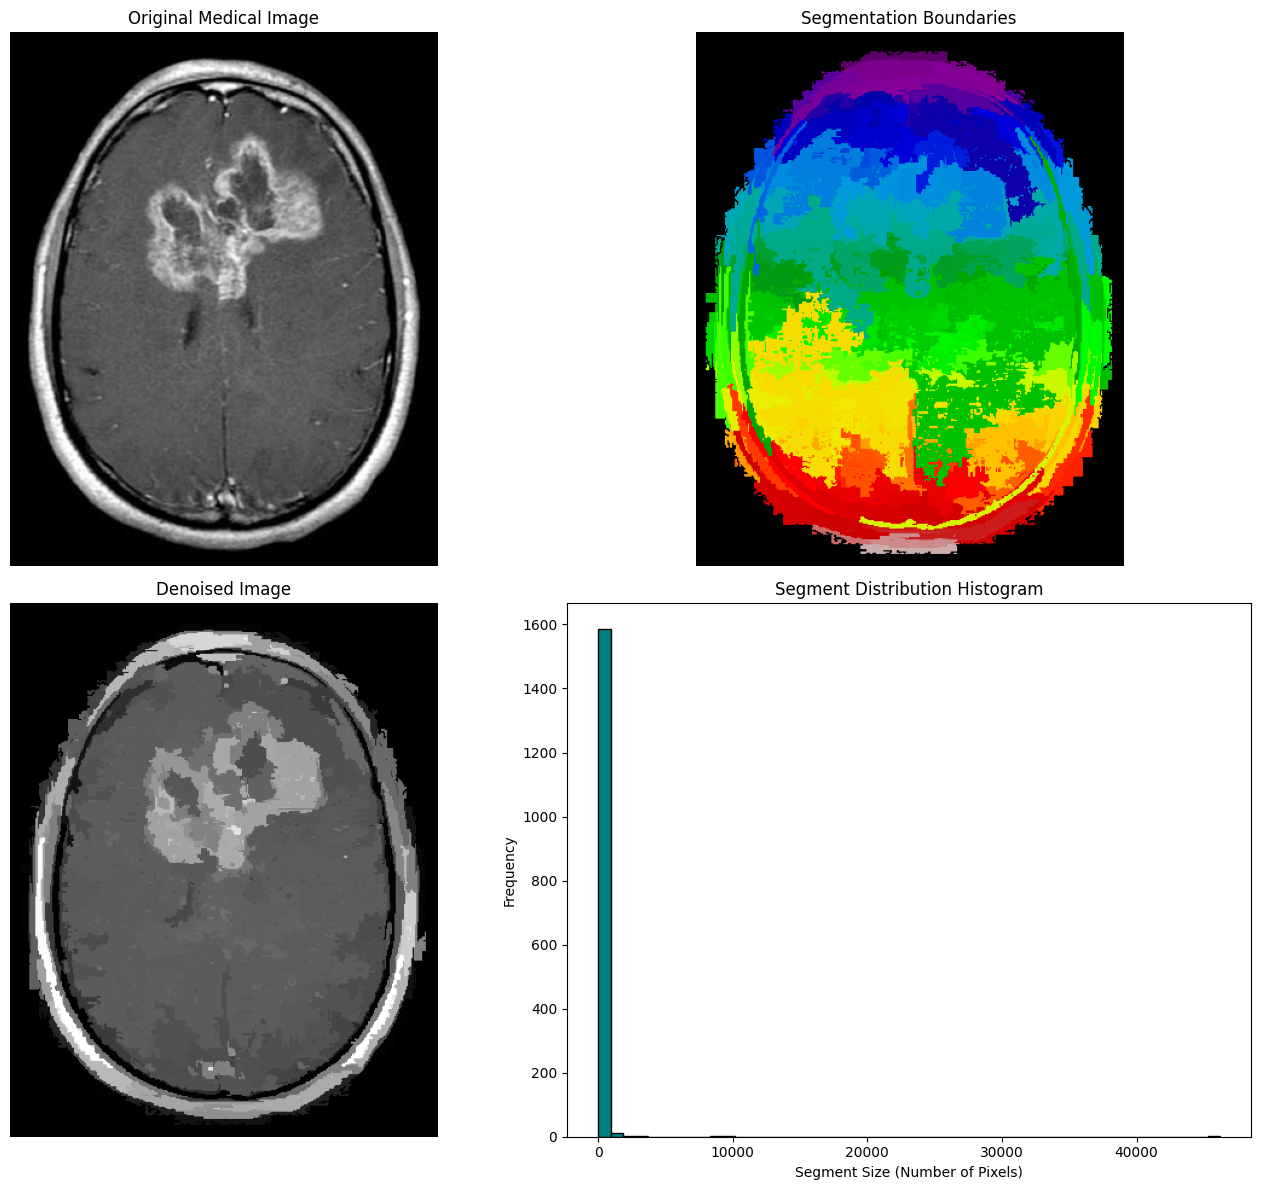


PROCESSING IMAGE: /content/Te-aug-me_1.jpg
Segmenting image with k=500...
Applying segment-based denoising...
------------------------------
QUANTITATIVE METRICS
------------------------------
Computation Time:   3.62 seconds
Number of Segments: 1269
Mean Squared Error: 200.62
PSNR:               25.11 dB
------------------------------


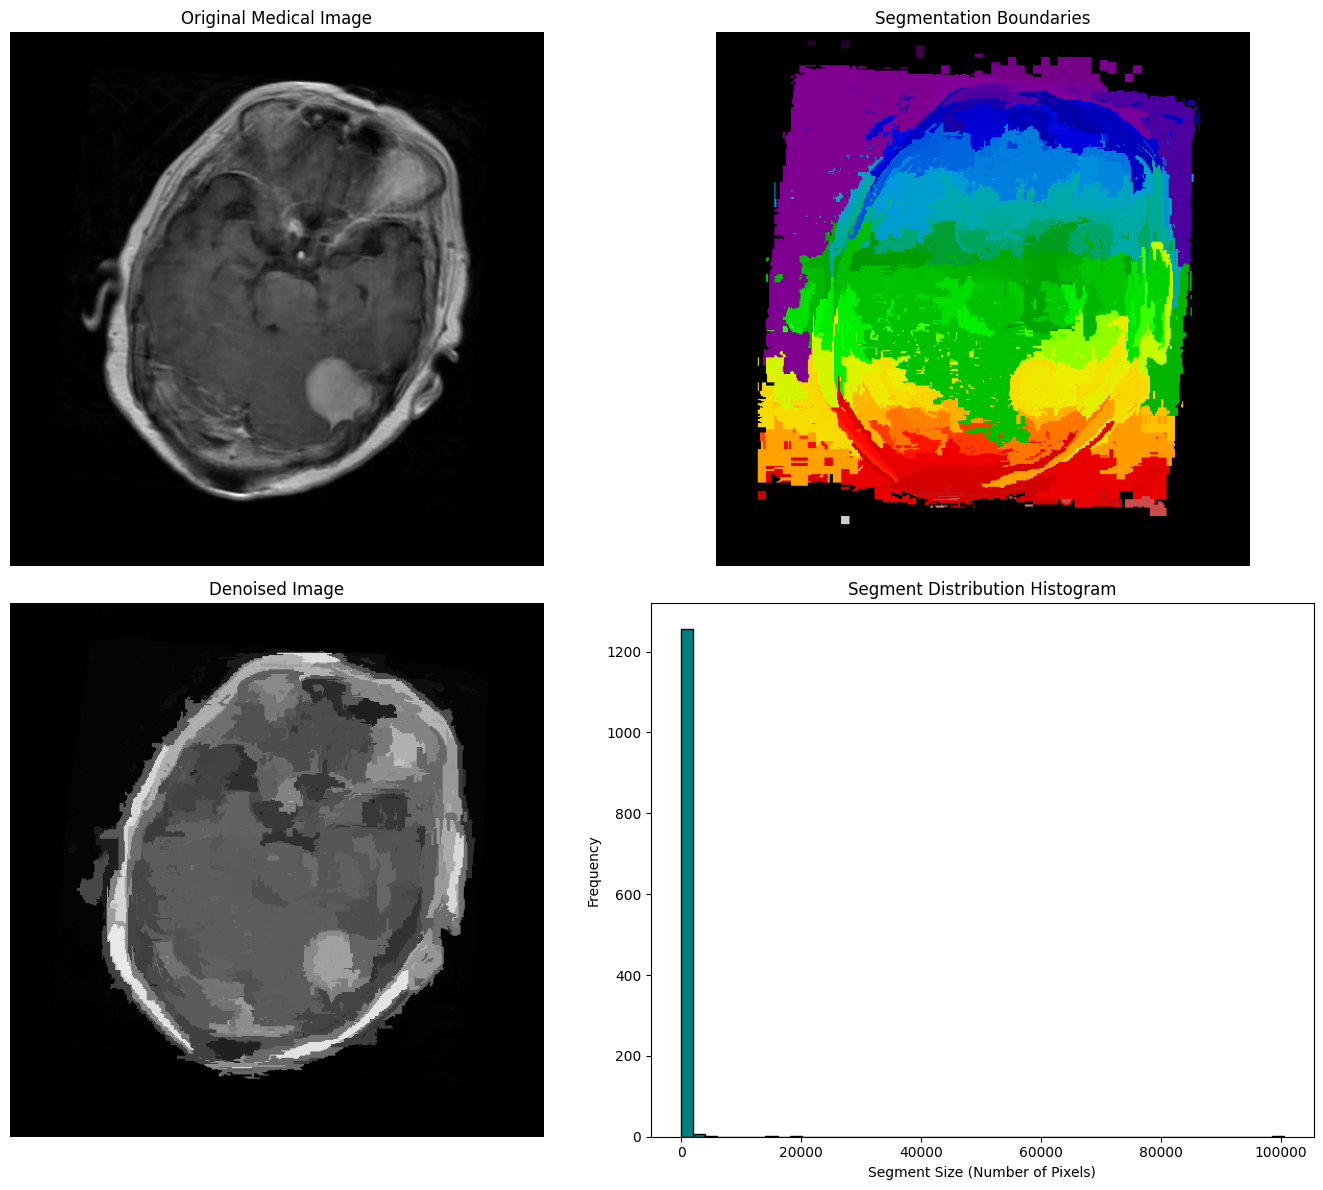

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from scipy import ndimage
from collections import defaultdict
import time
import math

# ==========================================
# 1. UNION-FIND DATA STRUCTURE
# ==========================================
class UnionFind:
    def __init__(self, size):
        self.parent = np.arange(size)
        self.size = np.ones(size)
        self.max_weight = np.zeros(size)

    def find(self, i):
        if self.parent[i] == i:
            return i
        self.parent[i] = self.find(self.parent[i])
        return self.parent[i]

    def union(self, i, j, weight):
        root_i = self.find(i)
        root_j = self.find(j)
        if root_i != root_j:
            # Attach smaller tree under root of larger tree
            if self.size[root_i] < self.size[root_j]:
                root_i, root_j = root_j, root_i

            self.parent[root_j] = root_i
            self.size[root_i] += self.size[root_j]
            # Update the maximum internal weight
            self.max_weight[root_i] = max(self.max_weight[root_i], self.max_weight[root_j], weight)

# ==========================================
# 2. GRAPH CONSTRUCTION & SEGMENTATION
# ==========================================
def build_graph(image):
    rows, cols = image.shape
    edges = []

    # Connect 4-neighbor pixels and calculate edge weights (intensity differences)
    for i in range(rows):
        for j in range(cols):
            u = i * cols + j
            if j + 1 < cols: # Right neighbor
                v = i * cols + (j + 1)
                weight = abs(float(image[i, j]) - float(image[i, j + 1]))
                edges.append((weight, u, v))
            if i + 1 < rows: # Bottom neighbor
                v = (i + 1) * cols + j
                weight = abs(float(image[i, j]) - float(image[i + 1, j]))
                edges.append((weight, u, v))
    return edges

def segment_image(image, k):
    rows, cols = image.shape
    num_pixels = rows * cols

    edges = build_graph(image)
    # Sort edges in non-decreasing order by weight
    edges.sort(key=lambda x: x[0])

    uf = UnionFind(num_pixels)

    # Modified Kruskal's merging logic
    for weight, u, v in edges:
        root_u = uf.find(u)
        root_v = uf.find(v)

        if root_u != root_v:
            tau_u = k / uf.size[root_u]
            tau_v = k / uf.size[root_v]

            # canMerge threshold criterion
            if weight <= min(uf.max_weight[root_u] + tau_u, uf.max_weight[root_v] + tau_v):
                uf.union(root_u, root_v, weight)

    return uf

# ==========================================
# 3. DENOISING & LABEL EXTRACTION
# ==========================================
def denoise_image(image, uf):
    rows, cols = image.shape
    denoised = np.zeros_like(image, dtype=np.float64)
    labels = np.zeros_like(image, dtype=np.int32)

    segment_sums = defaultdict(float)

    # Map pixels to segments and sum intensities
    for i in range(rows):
        for j in range(cols):
            pixel_idx = i * cols + j
            root = uf.find(pixel_idx)
            labels[i, j] = root
            segment_sums[root] += float(image[i, j])

    # Calculate segment means and assign to denoised image
    for i in range(rows):
        for j in range(cols):
            root = labels[i, j]
            mean_val = segment_sums[root] / uf.size[root]
            denoised[i, j] = mean_val

    return denoised, labels

# ==========================================
# 4. METRICS CALCULATION
# ==========================================
def calculate_metrics(original, denoised, labels):
    # Number of segments generated
    num_segments = len(np.unique(labels))

    # Mean Squared Error (MSE)
    mse = np.mean((original - denoised) ** 2)

    # Peak Signal-to-Noise Ratio (PSNR)
    if mse == 0:
        psnr = float('inf')
    else:
        max_pixel = 255.0
        psnr = 20 * math.log10(max_pixel / math.sqrt(mse))

    return num_segments, mse, psnr

# ==========================================
# 5. VISUALIZATION
# ==========================================
def visualize_results(original, labels, denoised):
    fig, axs = plt.subplots(2, 2, figsize=(14, 12))

    axs[0, 0].imshow(original, cmap='gray')
    axs[0, 0].set_title('Original Medical Image')
    axs[0, 0].axis('off')

    # Using nipy_spectral to clearly separate different segments
    axs[0, 1].imshow(labels, cmap='nipy_spectral')
    axs[0, 1].set_title('Segmentation Boundaries')
    axs[0, 1].axis('off')

    axs[1, 0].imshow(denoised, cmap='gray')
    axs[1, 0].set_title('Denoised Image')
    axs[1, 0].axis('off')

    unique_segments, counts = np.unique(labels, return_counts=True)
    axs[1, 1].hist(counts, bins=50, color='teal', edgecolor='black')
    axs[1, 1].set_title('Segment Distribution Histogram')
    axs[1, 1].set_xlabel('Segment Size (Number of Pixels)')
    axs[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# ==========================================
# 6. MAIN EXECUTION PIPELINE
# ==========================================
if __name__ == "__main__":
    print("Initializing MST-based Image Processing...")

    # UPDATE THESE PATHS to point to your uploaded Kaggle images in Colab
    # UPDATE THESE PATHS to match your uploaded files
    image_paths = [
        '/content/Te-no_1.jpg',
        '/content/Te-gl_1.jpg',
        '/content/Te-aug-me_1.jpg'
    ]

    k_parameter = 500  # Scale parameter k (tune this for parameter sensitivity analysis)

    for path in image_paths:
        print("\n" + "="*50)
        print(f"PROCESSING IMAGE: {path}")
        print("="*50)

        try:
            # Load the current image
            image = io.imread(path, as_gray=True) * 255

            # Start timer
            start_time = time.time()

            # Run pipeline
            print(f"Segmenting image with k={k_parameter}...")
            uf_structure = segment_image(image, k_parameter)

            print("Applying segment-based denoising...")
            denoised_img, segment_labels = denoise_image(image, uf_structure)

            # Stop timer
            computation_time = time.time() - start_time

            # Calculate metrics
            num_segments, mse, psnr = calculate_metrics(image, denoised_img, segment_labels)

            # Display results
            print("-" * 30)
            print("QUANTITATIVE METRICS")
            print("-" * 30)
            print(f"Computation Time:   {computation_time:.2f} seconds")
            print(f"Number of Segments: {num_segments}")
            print(f"Mean Squared Error: {mse:.2f}")
            print(f"PSNR:               {psnr:.2f} dB")
            print("-" * 30)

            # Render plots
            visualize_results(image, segment_labels, denoised_img)

        except FileNotFoundError:
            print(f"Error: Could not find '{path}'. Make sure it is uploaded to Colab and the path is correct!")